Conversion rate for Version A: 0.0280
Conversion rate for Version B: 0.0587
T-statistic: -4.1352
P-value: 0.0000
The result is statistically significant, meaning there is a significant difference between A and B.


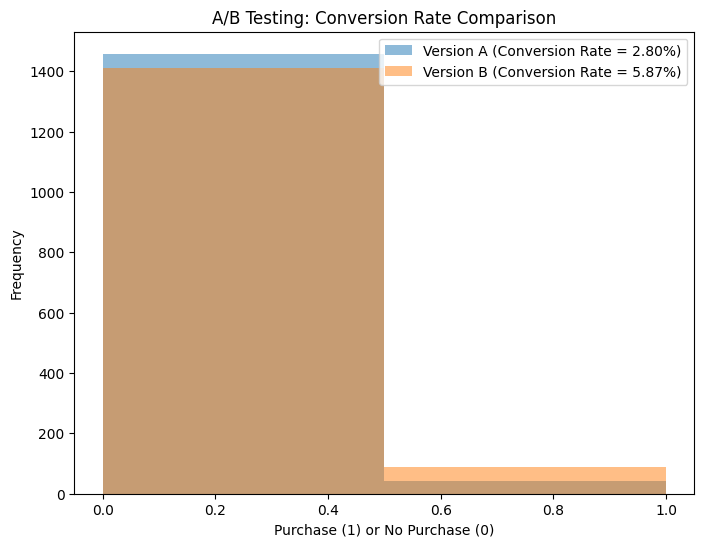

In [1]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import pandas as pd

# Step 1: Simulating Data
np.random.seed(42)  # For reproducibility

# Simulating a sample of 1,500 visitors for each layout (A and B)
n = 1500  # Sample size for each group

# Assume Version A has a 3% conversion rate (3% of visitors make a purchase)
# Assume Version B has a 5% conversion rate (5% of visitors make a purchase)
conversion_rate_A = 0.03
conversion_rate_B = 0.05

# Simulate purchases (1 for purchase, 0 for no purchase) for each group
group_A_purchases = np.random.binomial(1, conversion_rate_A, n)
group_B_purchases = np.random.binomial(1, conversion_rate_B, n)

# Step 2: Analyzing the Results
# Calculate the average conversion rate for each group
conversion_rate_A_actual = group_A_purchases.mean()
conversion_rate_B_actual = group_B_purchases.mean()

# Perform a two-sample t-test to see if the difference in conversion rates is statistically significant
t_stat, p_value = stats.ttest_ind(group_A_purchases, group_B_purchases)

# Step 3: Display Results
print(f"Conversion rate for Version A: {conversion_rate_A_actual:.4f}")
print(f"Conversion rate for Version B: {conversion_rate_B_actual:.4f}")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")

# Step 4: Interpretation of Results
if p_value < 0.05:
    print("The result is statistically significant, meaning there is a significant difference between A and B.")
else:
    print("The result is not statistically significant, meaning there is no significant difference between A and B.")

# Step 5: Visualize the Results
plt.figure(figsize=(8, 6))
plt.hist(group_A_purchases, bins=2, alpha=0.5, label='Version A (Conversion Rate = {:.2f}%)'.format(conversion_rate_A_actual * 100))
plt.hist(group_B_purchases, bins=2, alpha=0.5, label='Version B (Conversion Rate = {:.2f}%)'.format(conversion_rate_B_actual * 100))
plt.title('A/B Testing: Conversion Rate Comparison')
plt.xlabel('Purchase (1) or No Purchase (0)')
plt.ylabel('Frequency')
plt.legend()
plt.show()

# Step 6: Save the Results to a DataFrame for Further Analysis
data = pd.DataFrame({
    'Group_A_Purchases': group_A_purchases,
    'Group_B_Purchases': group_B_purchases
})
data.to_csv('ab_test_results_layout_comparison.csv', index=False)
